In [ ]:
# COPY ONLY THE REQUIRED CLASSES TO A WORKING DATASET

import os
import shutil

RAW_DATASET_DIR = "/content/drive/MyDrive/raw"

WORKING_DATASET_DIR = "/content/drive/MyDrive/working_dataset"


ALL_CLASSES = [
    "PETUNIA",
    "NAYANTARA",
    "BOUGAINVILLEA",
    "TAGAR",
    "GLEBIONIS CORONARIA",
    "HIBISCUS",
    "MARIGOLD",
    "GIANT CALOTROPE",
    "CHRYSANTHEMUM",
    "COSMOS"
]


IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
)


os.makedirs(WORKING_DATASET_DIR, exist_ok=True)

print("=" * 70)
print("Creating Working Dataset")
print("=" * 70)


for class_name in ALL_CLASSES:

    source_folder = os.path.join(RAW_DATASET_DIR, class_name)

    destination_folder = os.path.join(WORKING_DATASET_DIR, class_name)


    if not os.path.isdir(source_folder):
        print(f"❌ {class_name} folder not found.")
        continue

    if os.path.exists(destination_folder):
        shutil.rmtree(destination_folder)


    shutil.copytree(source_folder, destination_folder)

    image_count = sum(
        1
        for file in os.listdir(destination_folder)
        if file.lower().endswith(IMAGE_EXTENSIONS)
    )

    print(f"✅ {class_name:<25} -> {image_count} images copied")

print("\n" + "=" * 70)
print("Working dataset created successfully.")
print(f"Original Dataset : {RAW_DATASET_DIR}")
print(f"Working Dataset  : {WORKING_DATASET_DIR}")
print("The ORIGINAL dataset has NOT been modified.")
print("From now on, use WORKING_DATASET_DIR for every preprocessing step.")
print("=" * 70)

Creating Working Dataset
✅ PETUNIA                   -> 696 images copied
✅ NAYANTARA                 -> 618 images copied
✅ BOUGAINVILLEA             -> 468 images copied
✅ TAGAR                     -> 452 images copied
✅ GLEBIONIS CORONARIA       -> 328 images copied
✅ HIBISCUS                  -> 316 images copied
✅ MARIGOLD                  -> 304 images copied
✅ GIANT CALOTROPE           -> 261 images copied
✅ CHRYSANTHEMUM             -> 98 images copied
✅ COSMOS                    -> 94 images copied

Working dataset created successfully.
Original Dataset : /content/drive/MyDrive/raw
Working Dataset  : /content/drive/MyDrive/working_dataset
The ORIGINAL dataset has NOT been modified.
From now on, use WORKING_DATASET_DIR for every preprocessing step.


# **Mount Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("Done.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Done.


# Install Libraries

In [ ]:
!pip install imagehash --quiet

!pip install openpyxl --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 5.4 MB/s eta 0:00:00


# Import All Libraries

In [ ]:
import os
import shutil
import random
import cv2
import numpy as np
import imagehash
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt
import pandas as pd
from openpyxl import load_workbook

# Define All Paths + Fixed Numbers

In [ ]:

RAW_DIR        = "/content/drive/MyDrive/working_dataset"
REAL_WORLD_DIR = "/content/drive/MyDrive/real_world_test"
SPLITS_DIR     = "/content/drive/MyDrive/splits"
EXCEL_PATH     = "/content/drive/MyDrive/quality_scores.xlsx"



# ── Fixed Split Numbers ───────────────────────────────────────────
RESERVE = 10
VAL     = 20
TEST    = 30
TRAIN   = 400


CENTER_CROP_RATIO = 0.5
HASH_LIMIT        = 8

EXTREME_BLUR_PERCENTILE  = 5
COMBINED_BLUR_PERCENTILE = 15
BRIGHTNESS_MIN           = 60
BRIGHTNESS_MAX           = 190

ALL_CLASSES = [
    "PETUNIA", "NAYANTARA", "BOUGAINVILLEA", "TAGAR",
    "GLEBIONIS CORONARIA", "HIBISCUS", "MARIGOLD",
    "GIANT CALOTROPE", "CHRYSANTHEMUM", "COSMOS"
]
MAJORITY_CLASSES = ["PETUNIA", "NAYANTARA", "BOUGAINVILLEA", "TAGAR"]
MINORITY_CLASSES = [
    "GLEBIONIS CORONARIA", "HIBISCUS", "MARIGOLD",
    "GIANT CALOTROPE", "CHRYSANTHEMUM", "COSMOS"
]
LIGHT_CLASSES = {"GIANT CALOTROPE"}
VALID_EXT     = ('.jpg', '.jpeg', '.JPG', '.JPEG')

print("Deletion policy:")
print("  TAGAR         : EXCLUDED from all deletions")
print("  BOUGAINVILLEA : Duplicates only")
print("  PETUNIA       : Quality-based (blur + brightness)")
print("  NAYANTARA     : Quality-based (blur + brightness)")
print("All variables set.")

Deletion policy:
  TAGAR         : EXCLUDED from all deletions
  BOUGAINVILLEA : Duplicates only
  PETUNIA       : Quality-based (blur + brightness)
  NAYANTARA     : Quality-based (blur + brightness)
All variables set.


# Reserve 10 Images Per Class

In [ ]:
os.makedirs(REAL_WORLD_DIR, exist_ok=True)

for class_name in ALL_CLASSES:
    raw_path     = os.path.join(RAW_DIR, class_name)
    reserve_path = os.path.join(REAL_WORLD_DIR, class_name)
    os.makedirs(reserve_path, exist_ok=True)

    all_imgs = [f for f in os.listdir(raw_path) if f.endswith(VALID_EXT)]

    picked = random.sample(all_imgs, RESERVE)

    for img_name in picked:
        shutil.move(
            os.path.join(raw_path, img_name),
            os.path.join(reserve_path, img_name)
        )

    print(f"{class_name:<25}: {RESERVE} reserved | {len(all_imgs)-RESERVE} remain")

print("\nDone. Check real_world_test/ in Drive to confirm 10 per class.")

PETUNIA                  : 10 reserved | 686 remain
NAYANTARA                : 10 reserved | 608 remain
BOUGAINVILLEA            : 10 reserved | 458 remain
TAGAR                    : 10 reserved | 442 remain
GLEBIONIS CORONARIA      : 10 reserved | 318 remain
HIBISCUS                 : 10 reserved | 306 remain
MARIGOLD                 : 10 reserved | 294 remain
GIANT CALOTROPE          : 10 reserved | 251 remain
CHRYSANTHEMUM            : 10 reserved | 88 remain
COSMOS                   : 10 reserved | 84 remain

Done. Check real_world_test/ in Drive to confirm 10 per class.


# Generate Quality Score Excel — Majority Classes Only

In [ ]:
# Stage 1: Build report — no deletions happen in cells 5A through 5D

os.makedirs(os.path.dirname(EXCEL_PATH) if os.path.dirname(EXCEL_PATH) else ".", exist_ok=True)

rows = []
for class_name in MAJORITY_CLASSES:
    class_path = os.path.join(RAW_DIR, class_name)
    images     = [f for f in os.listdir(class_path) if f.endswith(VALID_EXT)]

    for img_name in images:
        rows.append({
            "Class"           : class_name,
            "Filename"        : img_name,
            "Blur Score"      : None,   # Filled by Cell 5B
            "Brightness Score": None,   # Filled by Cell 5C
            "Duplicate Flag"  : "",     # Filled by Cell 5D
            "Delete Reason"   : "",     # Filled by Cell 7
            "DELETE"          : ""      # Filled by Cell 7
        })

    print(f"{class_name:<25}: {len(images)} images added")

df = pd.DataFrame(rows)
df.to_excel(EXCEL_PATH, index=False)

print(f"\nExcel created → {EXCEL_PATH}")
print(f"Total rows : {len(df)}")
print("All score columns are empty — run Cell 5B next.")

PETUNIA                  : 686 images added
NAYANTARA                : 608 images added
BOUGAINVILLEA            : 458 images added
TAGAR                    : 442 images added

Excel created → /content/drive/MyDrive/quality_scores.xlsx
Total rows : 2194
All score columns are empty — run Cell 5B next.


# Visual Grid — 6 Worst Images Per Majority Class

In [ ]:
os.makedirs(os.path.dirname(EXCEL_PATH) if os.path.dirname(EXCEL_PATH) else ".", exist_ok=True)

rows = []
for class_name in MAJORITY_CLASSES:
    class_path = os.path.join(RAW_DIR, class_name)
    images     = [f for f in os.listdir(class_path) if f.endswith(VALID_EXT)]

    for img_name in images:
        rows.append({
            "Class"           : class_name,
            "Filename"        : img_name,
            "Blur Score"      : None,
            "Brightness Score": None,
            "Duplicate Flag"  : "",
            "Delete Reason"   : "",
            "DELETE"          : ""
        })

    print(f"{class_name:<25}: {len(images)} images added")

df = pd.DataFrame(rows)
df.to_excel(EXCEL_PATH, index=False)

print(f"\nExcel created → {EXCEL_PATH}")
print(f"Total rows : {len(df)}")
print("All score columns are empty — run Cell 5B next.")

PETUNIA                  : 686 images added
NAYANTARA                : 608 images added
BOUGAINVILLEA            : 458 images added
TAGAR                    : 442 images added

Excel created → /content/drive/MyDrive/quality_scores.xlsx
Total rows : 2194
All score columns are empty — run Cell 5B next.


In [ ]:
df = pd.read_excel(EXCEL_PATH)

blur_results = []
total = len(df)

for i, (_, row) in enumerate(df.iterrows()):
    img_path = os.path.join(RAW_DIR, row["Class"], row["Filename"])
    img      = cv2.imread(img_path)

    if img is None:
        blur_results.append(None)
        continue

    h, w   = img.shape[:2]
    mh     = int(h * (1 - CENTER_CROP_RATIO) / 2)
    mw     = int(w * (1 - CENTER_CROP_RATIO) / 2)

    centre = img[mh : h - mh, mw : w - mw]
    gray   = cv2.cvtColor(centre, cv2.COLOR_BGR2GRAY)
    score  = round(cv2.Laplacian(gray, cv2.CV_64F).var(), 2)
    blur_results.append(score)

    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/{total} images...")

df["Blur Score"] = blur_results
df.to_excel(EXCEL_PATH, index=False)

print("\nBlur score summary per class:")
for class_name in MAJORITY_CLASSES:
    s = df[df["Class"] == class_name]["Blur Score"].dropna()
    print(f"  {class_name:<25}: min={s.min():.1f}  max={s.max():.1f}  median={s.median():.1f}")

print("\nBlur Score column updated in Excel. Run Cell 5C next.")

  Processed 100/2194 images...
  Processed 200/2194 images...
  Processed 300/2194 images...
  Processed 400/2194 images...
  Processed 500/2194 images...
  Processed 600/2194 images...
  Processed 700/2194 images...
  Processed 800/2194 images...
  Processed 900/2194 images...
  Processed 1000/2194 images...
  Processed 1100/2194 images...
  Processed 1200/2194 images...
  Processed 1300/2194 images...
  Processed 1400/2194 images...
  Processed 1500/2194 images...
  Processed 1600/2194 images...
  Processed 1700/2194 images...
  Processed 1800/2194 images...
  Processed 1900/2194 images...
  Processed 2000/2194 images...
  Processed 2100/2194 images...

Blur score summary per class:
  PETUNIA                  : min=2.3  max=159.5  median=13.1
  NAYANTARA                : min=3.7  max=176.6  median=24.5
  BOUGAINVILLEA            : min=3.6  max=450.2  median=23.7
  TAGAR                    : min=7.0  max=314.0  median=30.2

Blur Score column updated in Excel. Run Cell 5C next.


In [ ]:
df = pd.read_excel(EXCEL_PATH)

brightness_results = []

for _, row in df.iterrows():
    img_path = os.path.join(RAW_DIR, row["Class"], row["Filename"])
    img      = cv2.imread(img_path)

    if img is None:
        brightness_results.append(None)
        continue

    gray       = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness = round(float(np.mean(gray)), 2)
    brightness_results.append(brightness)

df["Brightness Score"] = brightness_results
df.to_excel(EXCEL_PATH, index=False)

print("Brightness score summary per class:")
for class_name in MAJORITY_CLASSES:
    s    = df[df["Class"] == class_name]["Brightness Score"].dropna()
    dark = (s < BRIGHTNESS_MIN).sum()
    wash = (s > BRIGHTNESS_MAX).sum()
    print(f"  {class_name:<25}: min={s.min():.1f}  max={s.max():.1f}  |  dark<{BRIGHTNESS_MIN}: {dark}  washed>{BRIGHTNESS_MAX}: {wash}")

print("\nBrightness Score column updated in Excel. Run Cell 5D next.")

Brightness score summary per class:
  PETUNIA                  : min=69.4  max=175.2  |  dark<60: 0  washed>190: 0
  NAYANTARA                : min=75.0  max=164.9  |  dark<60: 0  washed>190: 0
  BOUGAINVILLEA            : min=46.8  max=176.7  |  dark<60: 1  washed>190: 0
  TAGAR                    : min=79.9  max=158.1  |  dark<60: 0  washed>190: 0

Brightness Score column updated in Excel. Run Cell 5D next.


In [ ]:
df = pd.read_excel(EXCEL_PATH)

dup_flags = [""] * len(df)

for class_name in MAJORITY_CLASSES:
    class_mask = df["Class"] == class_name
    class_df   = df[class_mask]

    hashes  = {}
    to_flag = set()

    for df_idx, row in class_df.iterrows():
        img_path = os.path.join(RAW_DIR, class_name, row["Filename"])
        try:
            hashes[df_idx] = imagehash.phash(Image.open(img_path))
        except:
            continue

    idx_list = list(hashes.keys())
    for i in range(len(idx_list)):
        for j in range(i + 1, len(idx_list)):
            dist = hashes[idx_list[i]] - hashes[idx_list[j]]
            if dist <= HASH_LIMIT and idx_list[j] not in to_flag:
                to_flag.add(idx_list[j])

    for df_idx in to_flag:
        pos = df.index.get_loc(df_idx)
        dup_flags[pos] = "DUPLICATE"

    print(f"{class_name:<25}: {len(to_flag)} duplicates flagged")

df["Duplicate Flag"] = dup_flags
df.to_excel(EXCEL_PATH, index=False)

print(f"\nQuality report complete → {EXCEL_PATH}")
print("Review Blur Score, Brightness Score, Duplicate Flag columns.")
print("Then run Cell 6 for visuals, and Cell 7 to mark DELETE column.")

PETUNIA                  : 15 duplicates flagged
NAYANTARA                : 29 duplicates flagged
BOUGAINVILLEA            : 3 duplicates flagged
TAGAR                    : 32 duplicates flagged

Quality report complete → /content/drive/MyDrive/quality_scores.xlsx
Review Blur Score, Brightness Score, Duplicate Flag columns.
Then run Cell 6 for visuals, and Cell 7 to mark DELETE column.


# Read Marked Excel — Delete Bad Images

In [ ]:
# Stage 2: Budget-aware DELETE marking — no files deleted yet
# Combined quality score = 70% blur rank + 30% brightness deviation
# Images are ranked worst to best, then marked up to class budget

df = pd.read_excel(EXCEL_PATH)

# Reset columns so we start clean
df["DELETE"]        = ""
df["Delete Reason"] = ""

# ── Deletion budgets per class — set from actual image counts ─────
# Budget = total images after reserve - minimum needed (val+test+train)
DELETE_BUDGET = {
    "PETUNIA"      : 236,   # 686 total - 450 min = 236 can delete
    "NAYANTARA"    : 158,   # 608 total - 450 min = 158 can delete
    "BOUGAINVILLEA": 8,     # 458 total - 450 min = 8 can delete
    "TAGAR"        : 0      # Excluded — training count already tight
}

# BOUGAINVILLEA split: 3 duplicates already found + 5 worst quality
BOUG_DUP_BUDGET   = 3
BOUG_EXTRA_BUDGET = 5

print(f"{'CLASS':<25} {'BUDGET':>8} {'MARKED':>8}  STRATEGY")
print("=" * 70)

for class_name in MAJORITY_CLASSES:
    budget     = DELETE_BUDGET.get(class_name, 0)
    class_mask = df["Class"] == class_name
    class_df   = df[class_mask].copy()
    marked     = 0

    # ── TAGAR: completely excluded ────────────────────────────────
    if budget == 0:
        print(f"{class_name:<25} {budget:>8} {0:>8}  EXCLUDED")
        continue

    # ── BOUGAINVILLEA: exactly 3 dupes + 5 worst quality ─────────
    if class_name == "BOUGAINVILLEA":
        # Step A: Mark the 3 confirmed duplicates first
        dup_indices = class_df[class_df["Duplicate Flag"] == "DUPLICATE"].index
        for idx in list(dup_indices)[:BOUG_DUP_BUDGET]:
            df.at[idx, "DELETE"]        = "DELETE"
            df.at[idx, "Delete Reason"] = "duplicate"
            marked += 1

        # Step B: From remaining non-duplicate images, find 5 worst by combined score
        already_marked = df[(class_mask) & (df["DELETE"] == "DELETE")].index
        remaining_df   = class_df[~class_df.index.isin(already_marked)].copy()

        blurs = sorted(remaining_df["Blur Score"].dropna().tolist())
        n     = len(blurs)

        def blur_rank(v):
            # 0 = blurriest (worst), 1 = sharpest (best)
            try:
                return blurs.index(v) / max(n - 1, 1)
            except:
                return 0.5

        def brightness_deviation(v):
            # 0 = ideal brightness, 1 = worst brightness
            if v is None or (hasattr(v, '__class__') and v.__class__.__name__ == 'float' and v != v):
                return 0.0
            ideal_low, ideal_high = 80, 160
            if ideal_low <= v <= ideal_high:
                return 0.0
            if v < ideal_low:
                return (ideal_low - v) / ideal_low
            return (v - ideal_high) / 95.0

        scores = []
        for idx, row in remaining_df.iterrows():
            blur = row["Blur Score"]
            bri  = row["Brightness Score"]
            if blur is None or (isinstance(blur, float) and blur != blur):
                continue
            br = blur_rank(blur)
            bd = brightness_deviation(bri) if bri is not None else 0.0
            # badness: 1 = worst, 0 = best
            badness = 0.7 * (1 - br) + 0.3 * bd
            scores.append((badness, idx))

        # Sort worst first, take top BOUG_EXTRA_BUDGET
        scores.sort(reverse=True)
        for badness, idx in scores[:BOUG_EXTRA_BUDGET]:
            blur_val = df.at[idx, "Blur Score"]
            bri_val  = df.at[idx, "Brightness Score"]
            df.at[idx, "DELETE"]        = "DELETE"
            df.at[idx, "Delete Reason"] = f"worst quality score={badness:.3f} blur={blur_val:.1f} bri={bri_val:.1f}"
            marked += 1

        print(f"{class_name:<25} {budget:>8} {marked:>8}  {BOUG_DUP_BUDGET} duplicates + {BOUG_EXTRA_BUDGET} worst quality")
        continue

    # ── PETUNIA / NAYANTARA: rank all by combined score, mark up to budget ──
    valid_rows = class_df.dropna(subset=["Blur Score"]).copy()

    blurs_all = sorted(valid_rows["Blur Score"].tolist())
    n_all     = len(blurs_all)

    def blur_rank_all(v):
        try:
            return blurs_all.index(v) / max(n_all - 1, 1)
        except:
            return 0.5

    def brightness_dev_all(v):
        if v is None or (isinstance(v, float) and v != v):
            return 0.0
        if 80 <= v <= 160:
            return 0.0
        if v < 80:
            return (80 - v) / 80.0
        return (v - 160) / 95.0

    scores_all = []
    for idx, row in valid_rows.iterrows():
        blur = row["Blur Score"]
        bri  = row["Brightness Score"]
        dup  = row["Duplicate Flag"]
        br   = blur_rank_all(blur)
        bd   = brightness_dev_all(bri) if bri is not None else 0.0
        # badness score: higher = worse image
        badness = 0.7 * (1 - br) + 0.3 * bd
        scores_all.append((badness, blur, bri, dup, idx))

    # Sort worst first
    scores_all.sort(reverse=True)

    # Mark up to budget — duplicates always included in count
    for badness, blur, bri, dup, idx in scores_all[:budget]:
        reasons = []
        if dup == "DUPLICATE":
            reasons.append("duplicate")
        reasons.append(f"quality score={badness:.3f} blur={blur:.1f} bri={bri:.1f}")

        df.at[idx, "DELETE"]        = "DELETE"
        df.at[idx, "Delete Reason"] = ", ".join(reasons)
        marked += 1

    print(f"{class_name:<25} {budget:>8} {marked:>8}  Combined score (blur 70% + brightness 30%)")

print("=" * 70)

df.to_excel(EXCEL_PATH, index=False)

print(f"\nExcel updated → {EXCEL_PATH}")
print("Open it. Review DELETE column and Delete Reason.")
print("When satisfied → run Cell 7B to permanently delete.")

CLASS                       BUDGET   MARKED  STRATEGY
PETUNIA                        236      236  Combined score (blur 70% + brightness 30%)
NAYANTARA                      158      158  Combined score (blur 70% + brightness 30%)
BOUGAINVILLEA                    8        8  3 duplicates + 5 worst quality
TAGAR                            0        0  EXCLUDED

Excel updated → /content/drive/MyDrive/quality_scores.xlsx
Open it. Review DELETE column and Delete Reason.
When satisfied → run Cell 7B to permanently delete.


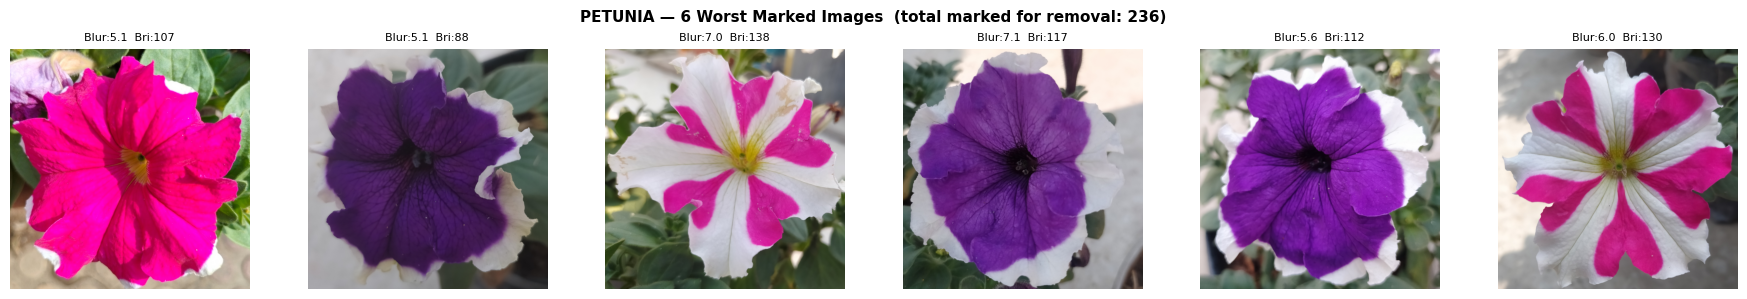

PETUNIA: showing 6 of 236 marked images



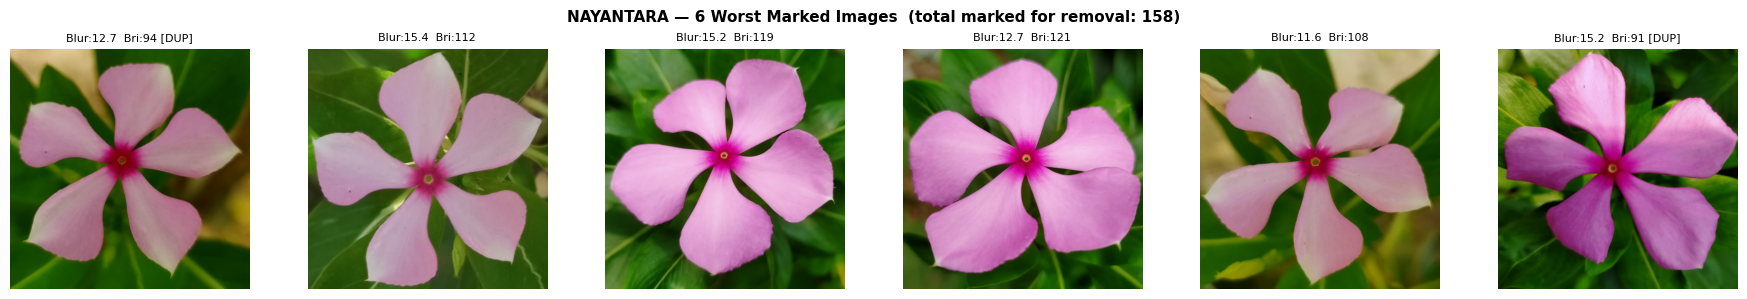

NAYANTARA: showing 6 of 158 marked images



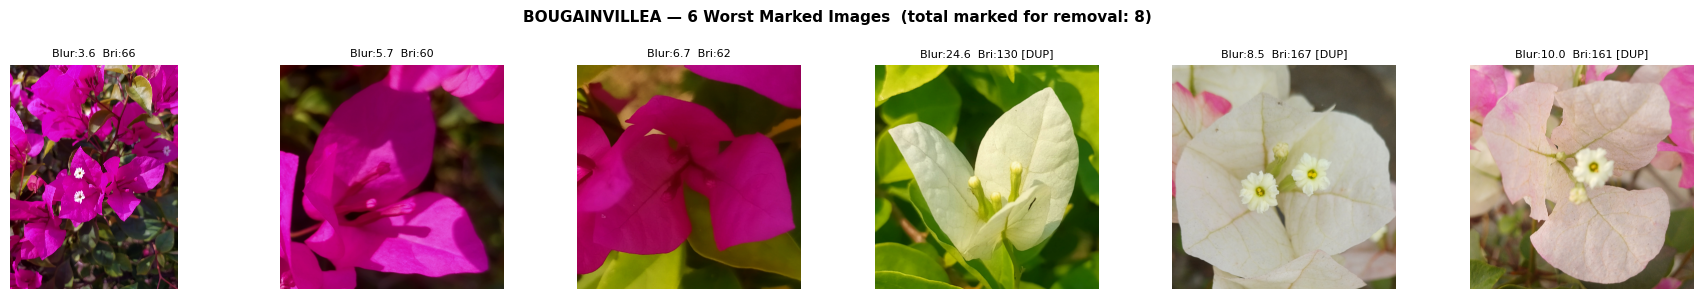

BOUGAINVILLEA: showing 6 of 8 marked images

Visual check complete.
If images look correct → run Cell 7B to transfer them out.


In [ ]:
# Shows 6 worst images per class from DELETE-marked rows
# TAGAR is excluded — not shown

SHOW          = 6          # How many worst images to display per class
SHOW_CLASSES  = ["PETUNIA", "NAYANTARA", "BOUGAINVILLEA"]   # Only these three

df = pd.read_excel(EXCEL_PATH)

for class_name in SHOW_CLASSES:
    # Get only the DELETE-marked rows for this class
    marked_df = df[
        (df["Class"] == class_name) & (df["DELETE"] == "DELETE")
    ].copy()

    if marked_df.empty:
        print(f"{class_name}: No images marked DELETE — skipping.")
        continue

    total_marked = len(marked_df)

    # Sort by Delete Reason to get actual worst first
    # (They are already sorted worst-first from Cell 7 output)
    show_rows = marked_df.head(SHOW)

    fig, axes = plt.subplots(1, SHOW, figsize=(18, 3))
    fig.suptitle(
        f"{class_name} — {SHOW} Worst Marked Images  "
        f"(total marked for removal: {total_marked})",
        fontsize=11, fontweight='bold'
    )

    for i, (_, row) in enumerate(show_rows.iterrows()):
        img_path = os.path.join(RAW_DIR, class_name, row["Filename"])
        img      = cv2.imread(img_path)

        if img is None:
            axes[i].set_title("File not found", fontsize=8)
            axes[i].axis('off')
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img_rgb)

        # Show scores and duplicate flag above each thumbnail
        dup_label = " [DUP]" if row["Duplicate Flag"] == "DUPLICATE" else ""
        axes[i].set_title(
            f"Blur:{row['Blur Score']:.1f}  "
            f"Bri:{row['Brightness Score']:.0f}"
            f"{dup_label}",
            fontsize=8
        )
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()
    print(f"{class_name}: showing 6 of {total_marked} marked images\n")

print("Visual check complete.")
print("If images look correct → run Cell 7B to transfer them out.")

In [ ]:
# SAFE TRANSFER — moves files, does NOT delete permanently
# Images go to quarantine/ folder — recoverable any time

# Quarantine folder sits alongside your raw/ folder in Drive
QUARANTINE_DIR = "/content/drive/MyDrive/quarantine"

# Create quarantine subfolders for all majority classes upfront
for class_name in MAJORITY_CLASSES:
    os.makedirs(os.path.join(QUARANTINE_DIR, class_name), exist_ok=True)

wb = load_workbook(EXCEL_PATH)
ws = wb.active

# Find column positions from header row
header    = [cell.value for cell in ws[1]]
del_col   = header.index("DELETE")
class_col = header.index("Class")
file_col  = header.index("Filename")

moved_count = {c: 0 for c in MAJORITY_CLASSES}
not_found   = 0

for row in ws.iter_rows(min_row=2, values_only=True):
    delete_value = row[del_col]

    # Only process rows marked DELETE
    if delete_value and str(delete_value).strip() == "DELETE":
        class_name = row[class_col]
        filename   = row[file_col]

        src = os.path.join(RAW_DIR,        class_name, filename)  # Current location
        dst = os.path.join(QUARANTINE_DIR, class_name, filename)  # Quarantine location

        if os.path.exists(src):
            shutil.move(src, dst)   # MOVE — not delete
            moved_count[class_name] += 1
        else:
            not_found += 1

# Print final summary
print(f"{'CLASS':<25} {'MOVED OUT':>10} {'REMAINING':>10} {'STATUS':>12}")
print("=" * 60)

for class_name in MAJORITY_CLASSES:
    class_path = os.path.join(RAW_DIR, class_name)
    remaining  = len([f for f in os.listdir(class_path) if f.endswith(VALID_EXT)])
    status     = "✅ OK" if remaining >= 450 else "⚠ CHECK"
    print(f"{class_name:<25} {moved_count[class_name]:>10} {remaining:>10} {status:>12}")

print("=" * 60)
print(f"Not found (already moved) : {not_found}")
print(f"\nQuarantine folder : {QUARANTINE_DIR}")
print("Raw folder now has clean images only.")
print("Proceed to Cell 8 for train/val/test split.")

CLASS                      MOVED OUT  REMAINING       STATUS
PETUNIA                          236        450         ✅ OK
NAYANTARA                        158        450         ✅ OK
BOUGAINVILLEA                      8        450         ✅ OK
TAGAR                              0        442      ⚠ CHECK
Not found (already moved) : 0

Quarantine folder : /content/drive/MyDrive/quarantine
Raw folder now has clean images only.
Proceed to Cell 8 for train/val/test split.
